In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, f_classif
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, confusion_matrix, classification_report)

In [39]:
plt.style.use('default')
sns.set_palette("Set2")
np.random.seed(42)

In [40]:
df = pd.read_csv('air_quality_new_dataset.csv')

In [41]:
print("Dataset Loaded")
print("Shape:", df.shape)
print(df.head())
print("\nColumn Names:", df.columns.tolist())

Dataset Loaded
Shape: (1060, 10)
        CO2        NO2  TEMPERATURE   HUMIDITY      PM2.5        PM10  \
0  1.518630  56.841123    21.258148  64.891639   8.046328   50.220630   
1  0.245631  41.148329    24.711794        NaN  18.256189    0.000000   
2  1.590041  -0.336604    28.726544  55.746668  99.070981   67.271799   
3  0.774381  59.249483    34.029814  46.347051  27.002722  171.080898   
4  0.735228  35.969293          NaN  79.366808  73.774756  186.748922   

         SO2         O3  WIND_SPEED AIR_QUALITY  
0  33.154245  24.425165    1.450581    Moderate  
1  14.647185  64.451439    6.977132        Good  
2  34.208575  23.736400    2.981163        Poor  
3  11.889519  50.285071    4.891567    Moderate  
4  28.008081  40.592361    5.941749    Moderate  

Column Names: ['CO2', 'NO2', 'TEMPERATURE', 'HUMIDITY', 'PM2.5', 'PM10', 'SO2', 'O3', 'WIND_SPEED', 'AIR_QUALITY']



 Statistical Summary:
            CO2       NO2  TEMPERATURE  HUMIDITY     PM2.5      PM10  \
count  1006.000  1003.000     1001.000   998.000  1005.000  1004.000   
mean      1.102    35.842       24.739    55.367    78.397   107.519   
std       0.600    18.767        6.442    16.188    47.244    60.244   
min      -0.443    -0.424       -7.997    30.002     0.000     0.000   
25%       0.628    22.341       20.191    42.194    41.048    59.182   
50%       1.112    35.741       24.934    55.010    75.998   105.027   
75%       1.560    47.913       29.838    67.105   113.056   152.049   
max       8.627   296.812       34.956   141.042   471.509   558.308   

            SO2        O3  WIND_SPEED  
count  1005.000  1004.000    1005.000  
mean     26.315    44.348       5.456  
std      15.197    22.609       2.525  
min      -0.309     0.000       1.000  
25%      14.607    26.302       3.369  
50%      25.704    43.672       5.461  
75%      38.188    60.041       7.529  
max     

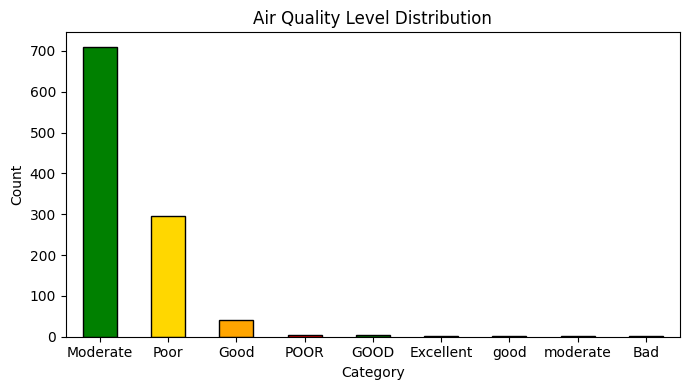

In [42]:
print("\n Statistical Summary:")
print(df.describe().round(3))

print("\n Missing Values Per Column:")
print(df.isnull().sum())
print(f"Total missing: {df.isnull().sum().sum()}")

print("\n AIR_QUALITY Distribution:")
print(df['AIR_QUALITY'].value_counts())

df['AIR_QUALITY'].value_counts().plot(
    kind='bar',
    color=['green', 'gold', 'orange', 'red'],
    edgecolor='black',
    figsize=(7, 4)
)
plt.title("Air Quality Level Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Cleaned Columns: ['CO2', 'NO2', 'TEMPERATURE', 'HUMIDITY', 'PM2_5', 'PM10', 'SO2', 'O3', 'WIND_SPEED', 'AIR_QUALITY']
  CO2: filled 54 missing values with median
  NO2: filled 57 missing values with median
  TEMPERATURE: filled 59 missing values with median
  HUMIDITY: filled 62 missing values with median
  PM2_5: filled 55 missing values with median
  PM10: filled 56 missing values with median
  SO2: filled 55 missing values with median
  O3: filled 56 missing values with median
  WIND_SPEED: filled 55 missing values with median

After filling — Missing Values: 509

🔧 Clipping Outliers...
  CO2: clipped 56 values → [-0.770, 2.958]
  NO2: clipped 61 values → [-16.015, 86.269]
  TEMPERATURE: clipped 68 values → [5.720, 44.309]
  HUMIDITY: clipped 73 values → [4.828, 104.471]
  PM2_5: clipped 60 values → [-66.965, 221.069]
  PM10: clipped 61 values → [-80.118, 291.348]
  SO2: clipped 56 values → [-20.763, 73.558]
  O3: clipped 60 values → [-24.307, 110.650]
  WIND_SPEED: clipped 55 valu

C:\Users\nikun\AppData\Local\Temp\ipykernel_32968\2065051141.py:10: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df[col].fillna(df[col].median(), inplace=True)


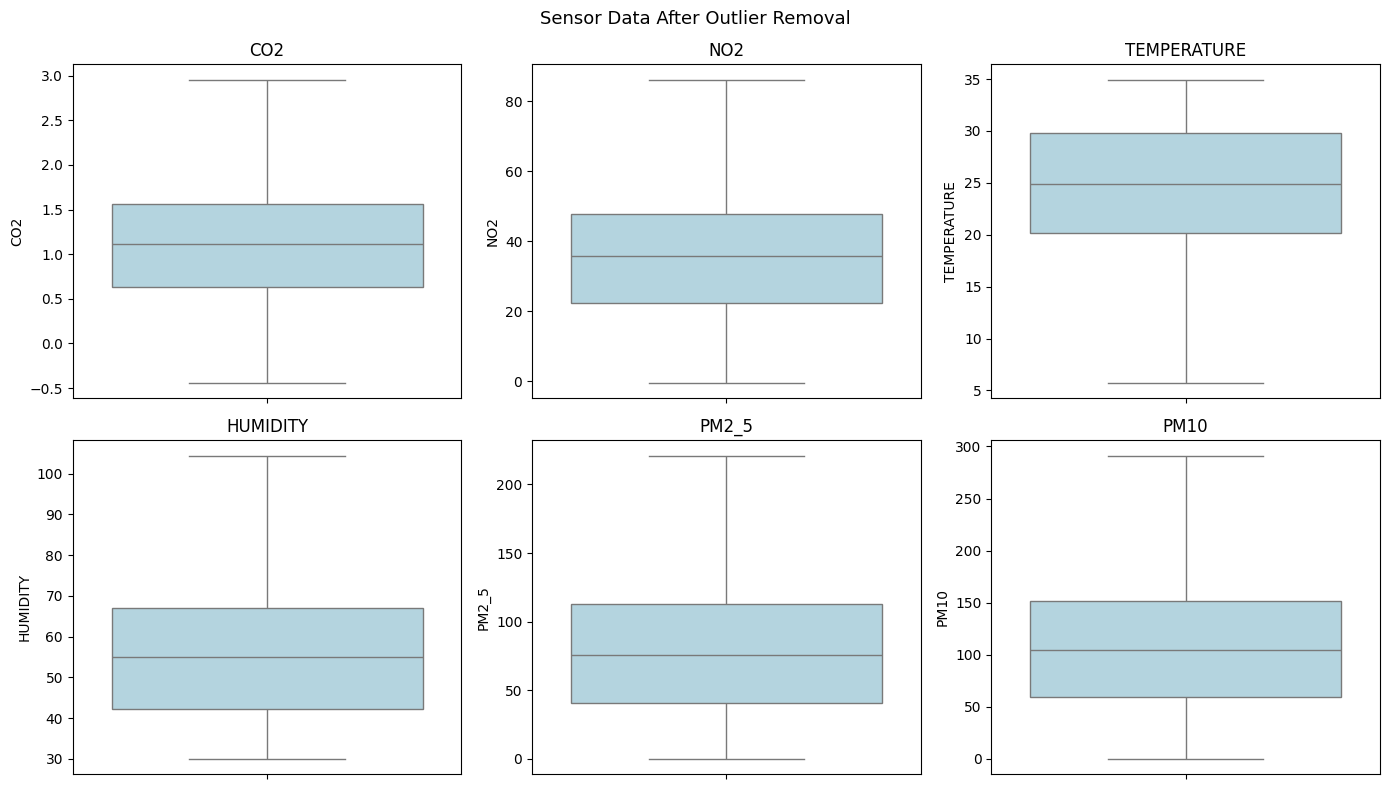


 Label Encoding:
  Bad → 0
  Excellent → 1
  GOOD → 2
  Good → 3
  Moderate → 4
  POOR → 5
  Poor → 6
  good → 7
  moderate → 8


In [43]:
df.columns = df.columns.str.strip().str.replace('.', '_').str.replace(' ', '_')
print("\nCleaned Columns:", df.columns.tolist())

numeric_cols = ['CO2', 'NO2', 'TEMPERATURE', 'HUMIDITY',
                'PM2_5', 'PM10', 'SO2', 'O3', 'WIND_SPEED']

for col in numeric_cols:
    missing = df[col].isnull().sum()
    if missing > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"  {col}: filled {missing} missing values with median")

print("\nAfter filling — Missing Values:", df.isnull().sum().sum())

print("\n🔧 Clipping Outliers...")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = df[col].copy()
    df[col] = df[col].clip(lower, upper)
    clipped = (before != df[col]).sum()
    print(f"  {col}: clipped {clipped} values → [{lower:.3f}, {upper:.3f}]")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flatten(), numeric_cols[:6]):
    sns.boxplot(y=df[col], ax=ax, color='lightblue')
    ax.set_title(f'{col}')
plt.suptitle("Sensor Data After Outlier Removal", fontsize=13)
plt.tight_layout()
plt.show()

le = LabelEncoder()
df['AIR_QUALITY_encoded'] = le.fit_transform(df['AIR_QUALITY'])
print("\n Label Encoding:")
for cls, num in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} → {num}")

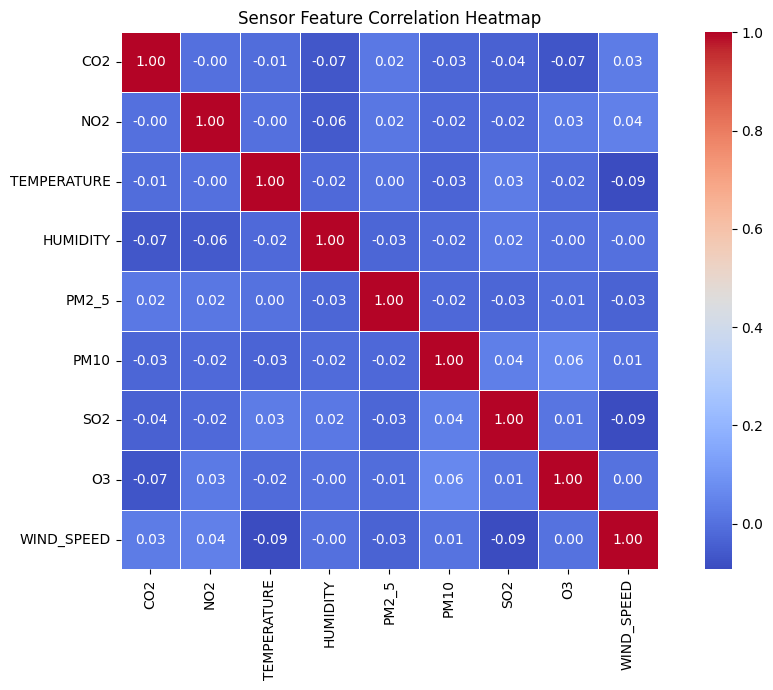

In [44]:
plt.figure(figsize=(10, 7))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, square=True)
plt.title("Sensor Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [45]:
print("Class Distribution:")
unique, counts = np.unique(y, return_counts=True)
for cls, cnt in zip(le.classes_, counts):
    print(f"  {cls}: {cnt} samples")
from collections import Counter

class_counts = Counter(y)
print("\nClass counts:", class_counts)

rare_classes = [cls for cls, cnt in class_counts.items() if cnt < 2]
print("  Rare classes (only 1 sample):", rare_classes)

if rare_classes:
    mask = np.isin(y, rare_classes, invert=True)
    X_selected_clean = X_selected[mask]
    y_clean = y[mask]
    print(f" Removed {sum(~mask)} rare-class rows")
    print(f" Remaining samples: {len(y_clean)}")
else:
    X_selected_clean = X_selected
    y_clean = y
    print(" No rare classes found")

min_class_count = min(Counter(y_clean).values())
print(f"\nMin samples in any class: {min_class_count}")

if min_class_count >= 2:
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected_clean, y_clean,
        test_size=0.2,
        random_state=42,
        stratify=y_clean       
    )
    print(" Split done WITH stratify")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X_selected_clean, y_clean,
        test_size=0.2,
        random_state=42
    )
    print(" Split done WITHOUT stratify (too few samples)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n Train Set : {X_train_scaled.shape}")
print(f" Test Set  : {X_test_scaled.shape}")

Class Distribution:
  Bad: 1 samples
  Excellent: 2 samples
  GOOD: 3 samples
  Good: 41 samples
  Moderate: 710 samples
  POOR: 4 samples
  Poor: 296 samples
  good: 2 samples
  moderate: 1 samples

Class counts: Counter({np.int64(4): 710, np.int64(6): 296, np.int64(3): 41, np.int64(5): 4, np.int64(2): 3, np.int64(1): 2, np.int64(7): 2, np.int64(8): 1, np.int64(0): 1})
  Rare classes (only 1 sample): [np.int64(8), np.int64(0)]
 Removed 2 rare-class rows
 Remaining samples: 1058

Min samples in any class: 2
 Split done WITH stratify

 Train Set : (846, 6)
 Test Set  : (212, 6)



Classification Report:
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        GOOD       0.00      0.00      0.00         1
        Good       1.00      0.50      0.67         8
    Moderate       0.88      0.94      0.91       142
        POOR       0.00      0.00      0.00         1
        Poor       0.82      0.78      0.80        59

    accuracy                           0.87       212
   macro avg       0.45      0.37      0.40       212
weighted avg       0.86      0.87      0.86       212



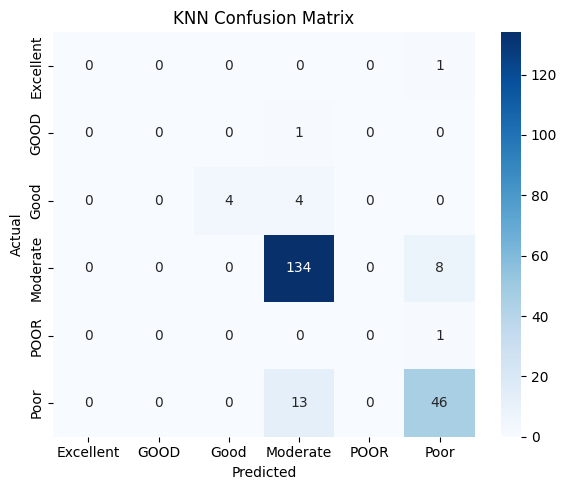

In [46]:
present_classes_indices = np.unique(y_test)
present_class_names = [le.classes_[i] for i in present_classes_indices]

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn,
                            labels=present_classes_indices,
                            target_names=present_class_names, 
                            zero_division=0))

plt.figure(figsize=(6, 5))
cm_knn = confusion_matrix(y_test, y_pred_knn, labels=present_classes_indices)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_class_names, 
            yticklabels=present_class_names)
plt.title("KNN Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()


 Best K = 8  |  Accuracy = 0.8915


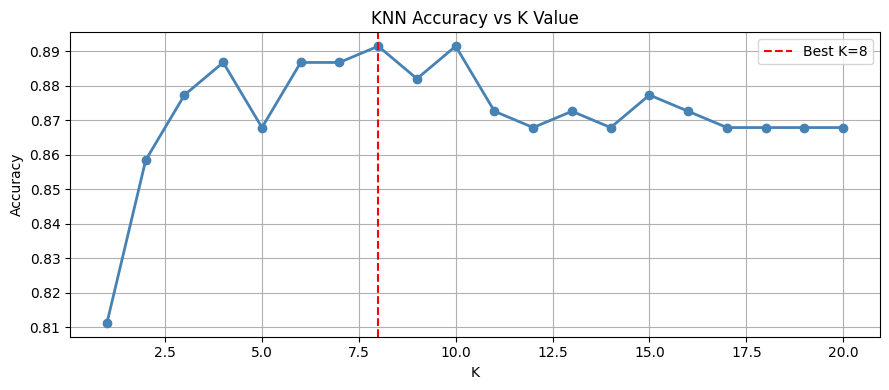

Best KNN Accuracy (K=8): 0.8915


In [47]:
k_range  = range(1, 21)
k_scores = []
for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    k_scores.append(accuracy_score(y_test, knn_k.predict(X_test_scaled)))

best_k = list(k_range)[np.argmax(k_scores)]
print(f"\n Best K = {best_k}  |  Accuracy = {max(k_scores):.4f}")

plt.figure(figsize=(9, 4))
plt.plot(k_range, k_scores, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.title("KNN Accuracy vs K Value")
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn_best.fit(X_train_scaled, y_train)
y_pred_knn_best = knn_best.predict(X_test_scaled)
print(f"Best KNN Accuracy (K={best_k}): {accuracy_score(y_test, y_pred_knn_best):.4f}")




Classification Report:
              precision    recall  f1-score   support

   Excellent       0.00      0.00      0.00         1
        GOOD       0.00      0.00      0.00         1
        Good       1.00      0.25      0.40         8
    Moderate       0.91      0.95      0.93       142
        POOR       0.00      0.00      0.00         1
        Poor       0.85      0.90      0.88        59

    accuracy                           0.90       212
   macro avg       0.46      0.35      0.37       212
weighted avg       0.89      0.90      0.88       212



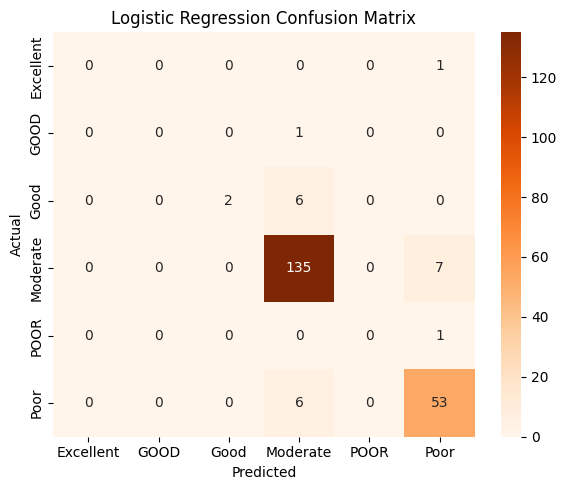

In [48]:
import numpy as np

present_classes_indices = np.unique(y_test)
present_class_names = [le.classes_[i] for i in present_classes_indices]


print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
                            labels=present_classes_indices,
                            target_names=present_class_names, 
                            zero_division=0))

plt.figure(figsize=(6, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=present_classes_indices)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=present_class_names, 
            yticklabels=present_class_names)
plt.title("Logistic Regression Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

              Model  Accuracy  Precision   Recall  F1 Score
          KNN (K=5)  0.867925   0.856833 0.867925  0.858375
     KNN (Best K=8)  0.891509   0.880383 0.891509  0.881647
Logistic Regression  0.896226   0.886616 0.896226  0.882513


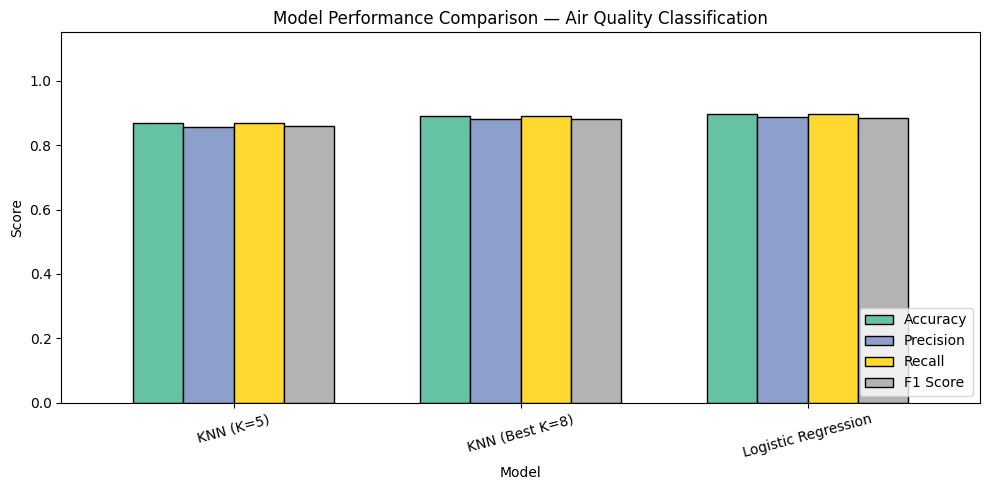

In [49]:
results = pd.DataFrame({
    'Model': ['KNN (K=5)', f'KNN (Best K={best_k})', 'Logistic Regression'],
    'Accuracy':  [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_knn_best),
        accuracy_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_knn,      average='weighted', zero_division=0),
        precision_score(y_test, y_pred_knn_best,  average='weighted', zero_division=0),
        precision_score(y_test, y_pred_lr,        average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, y_pred_knn,     average='weighted'),
        recall_score(y_test, y_pred_knn_best, average='weighted'),
        recall_score(y_test, y_pred_lr,       average='weighted')
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_knn,      average='weighted'),
        f1_score(y_test, y_pred_knn_best,  average='weighted'),
        f1_score(y_test, y_pred_lr,        average='weighted')
    ]
})

print(results.to_string(index=False))

results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black', width=0.7
)
plt.title("Model Performance Comparison — Air Quality Classification")
plt.ylabel("Score")
plt.ylim(0, 1.15)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
